# Description of Dataset

In [19]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('../datasets/tweets/tweets.csv')

In [21]:
df

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f
...,...,...,...,...,...,...,...,...,...
56566,1319485303363571714,RT @RandPaul: I don’t know why @JoeBiden think...,t,f,Twitter for iPhone,0,20683,2020-10-23 03:46:25,f
56567,1319484210101379072,RT @EliseStefanik: President @realDonaldTrump ...,t,f,Twitter for iPhone,0,9869,2020-10-23 03:42:05,f
56568,1319444420861829121,RT @TeamTrump: LIVE: Presidential Debate #Deba...,t,f,Twitter for iPhone,0,8197,2020-10-23 01:03:58,f
56569,1319384118849949702,Just signed an order to support the workers of...,f,f,Twitter for iPhone,176289,36001,2020-10-22 21:04:21,f


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56571 entries, 0 to 56570
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         56571 non-null  int64 
 1   text       56571 non-null  object
 2   isRetweet  56571 non-null  object
 3   isDeleted  56571 non-null  object
 4   device     56571 non-null  object
 5   favorites  56571 non-null  int64 
 6   retweets   56571 non-null  int64 
 7   date       56571 non-null  object
 8   isFlagged  56571 non-null  object
dtypes: int64(3), object(6)
memory usage: 3.9+ MB


In [23]:
df['date'] = pd.to_datetime(df['date'])
df['year_month']= df['date'].dt.to_period("M")


In [24]:
df.head()

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,year_month
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f,2011-08
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f,2020-03
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f,2020-01
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f,2020-09
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f,2020-01


### VADER (Valence Aware Dictionary and Sentiment Reasoner) 
##### est un outil de sentiment analysis basé sur un lexique [Rule-Based Approch].

In [25]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [26]:
model = SentimentIntensityAnalyzer()

In [27]:
def get_sentiment(text):
    scores = model.polarity_scores(text)
    return scores.get('compound')

In [28]:
%time df['sentiment'] = np.vectorize(get_sentiment)(df.text)

CPU times: user 5.96 s, sys: 9.2 ms, total: 5.97 s
Wall time: 6.32 s


In [29]:
df

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,year_month,sentiment
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f,2011-08,-0.1779
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f,2020-03,0.9792
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f,2020-01,0.0000
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f,2020-09,-0.9571
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f,2020-01,0.5413
...,...,...,...,...,...,...,...,...,...,...,...
56566,1319485303363571714,RT @RandPaul: I don’t know why @JoeBiden think...,t,f,Twitter for iPhone,0,20683,2020-10-23 03:46:25,f,2020-10,-0.5574
56567,1319484210101379072,RT @EliseStefanik: President @realDonaldTrump ...,t,f,Twitter for iPhone,0,9869,2020-10-23 03:42:05,f,2020-10,0.5423
56568,1319444420861829121,RT @TeamTrump: LIVE: Presidential Debate #Deba...,t,f,Twitter for iPhone,0,8197,2020-10-23 01:03:58,f,2020-10,0.0000
56569,1319384118849949702,Just signed an order to support the workers of...,f,f,Twitter for iPhone,176289,36001,2020-10-22 21:04:21,f,2020-10,-0.4678


### Export Data to datasets path

In [ ]:
df.to_csv("../datasets/tweets/exportSentimentTweets.csv")

# Visualization of extracted sentiment data

In [31]:
df_for_visualization = df.copy()

In [32]:
df_for_visualization

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,year_month,sentiment
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f,2011-08,-0.1779
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f,2020-03,0.9792
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f,2020-01,0.0000
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f,2020-09,-0.9571
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f,2020-01,0.5413
...,...,...,...,...,...,...,...,...,...,...,...
56566,1319485303363571714,RT @RandPaul: I don’t know why @JoeBiden think...,t,f,Twitter for iPhone,0,20683,2020-10-23 03:46:25,f,2020-10,-0.5574
56567,1319484210101379072,RT @EliseStefanik: President @realDonaldTrump ...,t,f,Twitter for iPhone,0,9869,2020-10-23 03:42:05,f,2020-10,0.5423
56568,1319444420861829121,RT @TeamTrump: LIVE: Presidential Debate #Deba...,t,f,Twitter for iPhone,0,8197,2020-10-23 01:03:58,f,2020-10,0.0000
56569,1319384118849949702,Just signed an order to support the workers of...,f,f,Twitter for iPhone,176289,36001,2020-10-22 21:04:21,f,2020-10,-0.4678


In [33]:
df_for_visualization = df_for_visualization.set_index("date")

In [34]:
df_for_visualization.index

DatetimeIndex(['2011-08-02 18:07:48', '2020-03-03 01:34:50',
               '2020-01-17 03:22:47', '2020-09-12 20:10:58',
               '2020-01-17 13:13:59', '2020-01-17 00:11:56',
               '2020-02-01 16:14:02', '2020-10-23 04:52:14',
               '2020-10-23 04:46:53', '2020-10-23 04:46:49',
               ...
               '2020-01-01 00:17:52', '2020-01-01 00:15:21',
               '2020-01-01 00:14:45', '2020-01-01 00:14:26',
               '2020-01-01 00:13:56', '2020-10-23 03:46:25',
               '2020-10-23 03:42:05', '2020-10-23 01:03:58',
               '2020-10-22 21:04:21', '2020-10-22 18:31:46'],
              dtype='datetime64[ns]', name='date', length=56571, freq=None)

/tmp/ipykernel_7322/3969323857.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_for_visualization['2011':]['sentiment'].resample('M').mean().plot()


Text(0, 0.5, 'Valeur du sentiment')

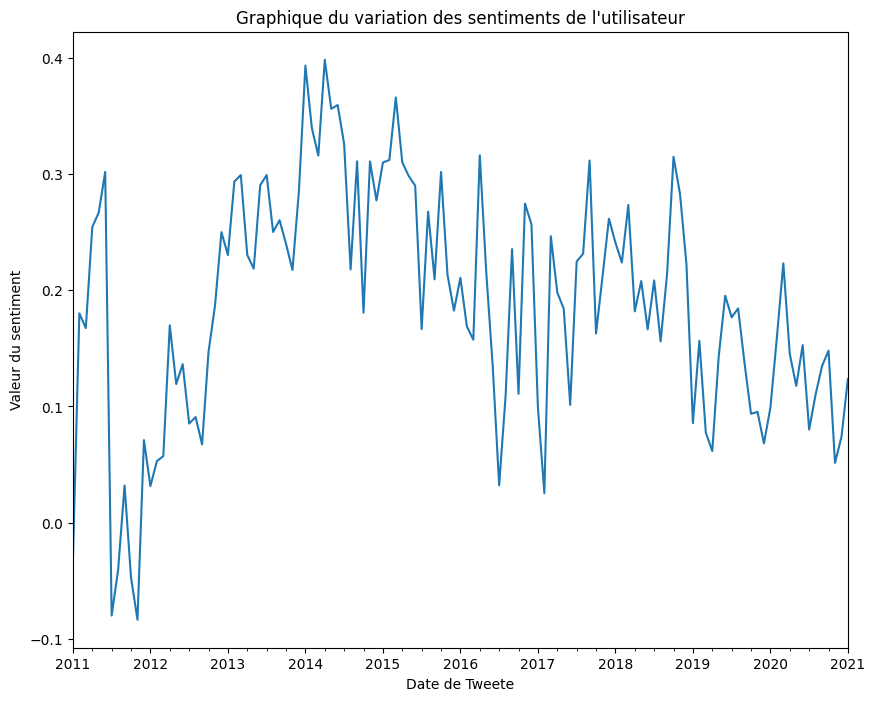

In [35]:
df_for_visualization = df_for_visualization.sort_index()

plt.figure(figsize=(10, 8))
df_for_visualization['2011':]['sentiment'].resample('M').mean().plot()
plt.title("Graphique du variation des sentiments de l'utilisateur")
plt.xlabel("Date de Tweete")
plt.ylabel("Valeur du sentiment")

#### Small visual of the analysis of the events wich caused the negative feeling

In [36]:
df.loc[df.year_month == '2017-02'].sort_values(by='sentiment', ascending=True).text.tolist()[:10]

['Everybody is arguing whether or not it is a BAN. Call it what you want, it is about keeping bad people (with bad intentions) out of country!',
 'Because the ban was lifted by a judge, many very bad and dangerous people may be pouring into our country. A terrible decision',
 'The FAKE NEWS media (failing @nytimes, @CNN, @NBCNews and many more)    is not my enemy, it is the enemy of the American people. SICK!',
 'The fake news media is going crazy with their conspiracy theories and blind hatred. @MSNBC &amp, @CNN are unwatchable. @foxandfriends is great!',
 '"Our legal system is broken! ""77% of refugees allowed into U.S. since travel reprieve hail from seven suspect countries."" (WT)  SO DANGEROUS!"',
 'While on FAKE NEWS @CNN, Bernie Sanders was cut off for using the term fake news to describe the network. They said technical difficulties!',
 'I will be speaking at 9:00 A.M. today to Police Chiefs and Sheriffs and will be discussing the horrible, dangerous and wrong decision.......',

#### Small visual of the analysis of the events wich caused the Positif feeling

In [38]:
df.loc[df.year_month == '2014-09'].sort_values(by='sentiment', ascending=True).text.tolist()[:10]

["The judge in the Oscar Pistorious case is a total moron. She said he didn't act like a killer. This is another O.J. disaster!",
 'Obama’s rollout of his ISIS war plan is another unmitigated disaster. The Generals must be furious.',
 '"""@Carmelcandi68: The ISIS thug who murdered Amer James Foley may hv been Gitmo detainee http://t.co/evsED2fAX5 yall want close gitmo so bad"""',
 '"Do you believe that Obama is giving weapons to ""moderate rebels"" in Syria.Isn\'t sure who they are. What the hell is he doing.Will turn on us"',
 'It is so sad to see what has happened to Atlantic City. So many bad decisions by the pols over the years - airport, convention center, etc.',
 '"""@NewMexicoRoni @realDonaldTrump sadly, they of course will blame you for the failure. Idiots.""  And I haven\'t been there in years."',
 "In '09, Obama released the ISIS chief. The terrorist gloated “I’ll see you in New York” http://t.co/OtWXYrlsoP Historic nat'l sec. error",
 'Secretary Kerry cannot get other nation

### Make [ Named-entity recognition ] 
#### to know what are the entities or organisation in the user a likes and not

In [39]:
import spacy

In [40]:
nlp = spacy.load('en_core_web_sm')

def get_entities(text):
    doc = nlp(text)
    list_ = []
    for ent in doc.ents:
        if ent.label_.lower() not in ('time', 'money', 'date'):
            temp_ = re.sub('[^a-z0-9]+', '_', ent.text.lower())
            list_.append('__'.join([temp_, ent.label_.upper()]))
    return ' '.join(list_)

In [41]:
%time df['entities'] = np.vectorize(get_entities)(df.text)

CPU times: user 7min 30s, sys: 114 ms, total: 7min 30s
Wall time: 7min 35s


In [42]:
df['is_positive'] = df.sentiment > 0

In [43]:
df

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,year_month,sentiment,entities,is_positive
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f,2011-08,-0.1779,republicans__NORP democrats__NORP,False
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f,2020-03,0.9792,charlotte__GPE north_carolina__GPE thousands__...,True
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f,2020-01,0.0000,cbs_news__ORG,False
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f,2020-09,-0.9571,the_unsolicited_mail_in_ballot_scam__ORG democ...,False
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f,2020-01,0.5413,comey__PERSON,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56566,1319485303363571714,RT @RandPaul: I don’t know why @JoeBiden think...,t,f,Twitter for iPhone,0,20683,2020-10-23 03:46:25,f,2020-10,-0.5574,,False
56567,1319484210101379072,RT @EliseStefanik: President @realDonaldTrump ...,t,f,Twitter for iPhone,0,9869,2020-10-23 03:42:05,f,2020-10,0.5423,rt_elisestefanik__PERSON _realdonaldtrump_exce...,True
56568,1319444420861829121,RT @TeamTrump: LIVE: Presidential Debate #Deba...,t,f,Twitter for iPhone,0,8197,2020-10-23 01:03:58,f,2020-10,0.0000,,False
56569,1319384118849949702,Just signed an order to support the workers of...,f,f,Twitter for iPhone,176289,36001,2020-10-22 21:04:21,f,2020-10,-0.4678,delphi_corporation__ORG american__NORP obama_b...,False


In [44]:
df['X'] = df.entities
df['y'] = df.is_positive

In [45]:
df

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,year_month,sentiment,entities,is_positive,X,y
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f,2011-08,-0.1779,republicans__NORP democrats__NORP,False,republicans__NORP democrats__NORP,False
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f,2020-03,0.9792,charlotte__GPE north_carolina__GPE thousands__...,True,charlotte__GPE north_carolina__GPE thousands__...,True
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f,2020-01,0.0000,cbs_news__ORG,False,cbs_news__ORG,False
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f,2020-09,-0.9571,the_unsolicited_mail_in_ballot_scam__ORG democ...,False,the_unsolicited_mail_in_ballot_scam__ORG democ...,False
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f,2020-01,0.5413,comey__PERSON,True,comey__PERSON,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56566,1319485303363571714,RT @RandPaul: I don’t know why @JoeBiden think...,t,f,Twitter for iPhone,0,20683,2020-10-23 03:46:25,f,2020-10,-0.5574,,False,,False
56567,1319484210101379072,RT @EliseStefanik: President @realDonaldTrump ...,t,f,Twitter for iPhone,0,9869,2020-10-23 03:42:05,f,2020-10,0.5423,rt_elisestefanik__PERSON _realdonaldtrump_exce...,True,rt_elisestefanik__PERSON _realdonaldtrump_exce...,True
56568,1319444420861829121,RT @TeamTrump: LIVE: Presidential Debate #Deba...,t,f,Twitter for iPhone,0,8197,2020-10-23 01:03:58,f,2020-10,0.0000,,False,,False
56569,1319384118849949702,Just signed an order to support the workers of...,f,f,Twitter for iPhone,176289,36001,2020-10-22 21:04:21,f,2020-10,-0.4678,delphi_corporation__ORG american__NORP obama_b...,False,delphi_corporation__ORG american__NORP obama_b...,False


In [47]:
df_regrouped = df.copy()

In [58]:
df_xy = df_regrouped[['X','y']]

In [65]:
word_count = pd.crosstab(df_xy['y'], df_xy['X'])

In [66]:
word_count

X,,000__CARDINAL,000__CARDINAL 000__CARDINAL,007__CARDINAL sean_connery__ORG scotland__GPE sean__NORP,09__CARDINAL,0_3__CARDINAL 6__CARDINAL,0_7___PERCENT,0__CARDINAL,0___PERCENT tim_ryan__PERSON 0___PERCENT _repswalwell__ORG,0bama__CARDINAL america__GPE,...,zero__GPE,zero__GPE ebola__GPE obama__GPE,zero__GPE http_t_co_bxsj6mkzgh__PERSON,zero__GPE the_trump_administration__ORG north_korea__GPE _nytimes__ORG,zimbabwe__GPE the_national_forest__ORG,zimmerman__PERSON while_zimmerman__PERSON,zinke__PERSON,zogby__GPE,zte__ORG chinese__NORP u_s___GPE china__GPE xi__PERSON,zuker__ORG
y,,,,,,,,,,,,,,,,,,,,,
False,5041,0,0,1,1,1,1,0,1,1,...,0,0,0,1,1,1,0,1,1,0
True,6255,1,1,0,0,0,0,1,0,0,...,1,1,1,0,0,0,1,0,0,1


In [59]:
df_regrouped

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,year_month,sentiment,entities,is_positive,X,y
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f,2011-08,-0.1779,republicans__NORP democrats__NORP,False,republicans__NORP democrats__NORP,False
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f,2020-03,0.9792,charlotte__GPE north_carolina__GPE thousands__...,True,charlotte__GPE north_carolina__GPE thousands__...,True
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f,2020-01,0.0000,cbs_news__ORG,False,cbs_news__ORG,False
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f,2020-09,-0.9571,the_unsolicited_mail_in_ballot_scam__ORG democ...,False,the_unsolicited_mail_in_ballot_scam__ORG democ...,False
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f,2020-01,0.5413,comey__PERSON,True,comey__PERSON,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56566,1319485303363571714,RT @RandPaul: I don’t know why @JoeBiden think...,t,f,Twitter for iPhone,0,20683,2020-10-23 03:46:25,f,2020-10,-0.5574,,False,,False
56567,1319484210101379072,RT @EliseStefanik: President @realDonaldTrump ...,t,f,Twitter for iPhone,0,9869,2020-10-23 03:42:05,f,2020-10,0.5423,rt_elisestefanik__PERSON _realdonaldtrump_exce...,True,rt_elisestefanik__PERSON _realdonaldtrump_exce...,True
56568,1319444420861829121,RT @TeamTrump: LIVE: Presidential Debate #Deba...,t,f,Twitter for iPhone,0,8197,2020-10-23 01:03:58,f,2020-10,0.0000,,False,,False
56569,1319384118849949702,Just signed an order to support the workers of...,f,f,Twitter for iPhone,176289,36001,2020-10-22 21:04:21,f,2020-10,-0.4678,delphi_corporation__ORG american__NORP obama_b...,False,delphi_corporation__ORG american__NORP obama_b...,False
